In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [3]:
df0 = pd.read_csv('sp500sub.csv', index_col = 'Date', parse_dates = True)

In [4]:
df0.head()

,Open,High,Low,Close,Adj Close,Volume,Name
Date,,,,,,,
2010-01-04,9.22,9.51,9.17,9.50,9.50,1865400.0,INCY
2010-01-05,9.51,10.29,9.45,10.27,10.27,7608900.0,INCY
2010-01-06,10.38,11.09,10.35,11.00,11.00,8046700.0,INCY
2010-01-07,11.00,11.06,10.62,10.82,10.82,3680300.0,INCY
2010-01-08,10.82,11.00,10.75,10.94,10.94,1529300.0,INCY


In [5]:
df = df0[df0['Name']=='IBM'][['Close']].copy()

In [6]:
df['LogClose'] = np.log(df['Close'])

In [7]:
df['DiffLogClose'] = df['LogClose'].diff()

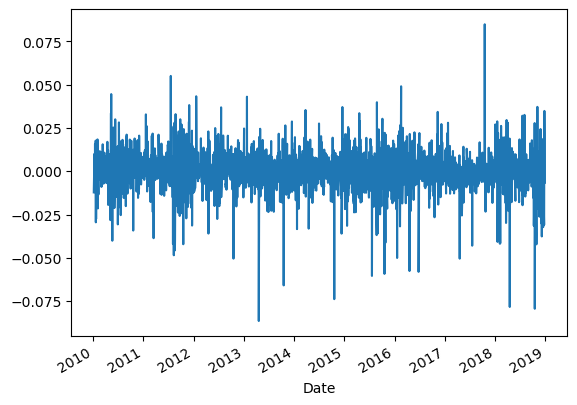

In [9]:
df['DiffLogClose'].plot();

In [12]:
''' these are stock prices, so we have to make it stationary.
else, without differencing, data will not be stationary and it will just predict the last value
'''

' these are stock prices, so we have to make it stationary.\nelse, without differencing, data will not be stationary and it will just predict the last value\n'

In [13]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [14]:
series =  df['DiffLogClose'].to_numpy()[1:] #1st value is 0 in differencing # converting this to numpy array since it is easy to index

T = 21
X = []
Y = []

for t in range(len(series)-T):
    x = series[t:t+T] # returns from t to t + T -1
    y = series[t+T] # returns t+T
    X.append(x)
    Y.append(y)

X = np.array(X).reshape(-1, T)
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (2241, 21) Y.shape (2241,)


In [15]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:] 

In [16]:
lr = LinearRegression()
lr.fit(Xtrain, Ytrain)
lr.score(Xtrain, Ytrain)

0.00910676388568643

In [17]:
lr.score(Xtest, Ytest)

-0.10647843085489184

In [18]:
''' both the train and test r2 is worse '''

' both the train and test r2 is worse '

In [19]:
train_idx = df.index <= train.index[-1]
test_idx = ~ train_idx
train_idx[:T+1] = False 
# 1st T+1 values are not predictable since model is trained to predict basis last T values
# remeber that the series object created has 1st data removed since its null

In [20]:
# need to compute un-differenced predictions  for itrain predictions for one step
df['ShiftLogClose'] = df['LogClose'].shift(1)
prev = df['ShiftLogClose']

In [21]:
last_train = train.iloc[-1]['LogClose']

In [22]:
# 1 step forecast
df.loc[train_idx, 'LR_1step_train'] =  prev[train_idx] + lr.predict(Xtrain)
df.loc[test_idx, 'LR_1step_test'] =  prev[test_idx] + lr.predict(Xtest)

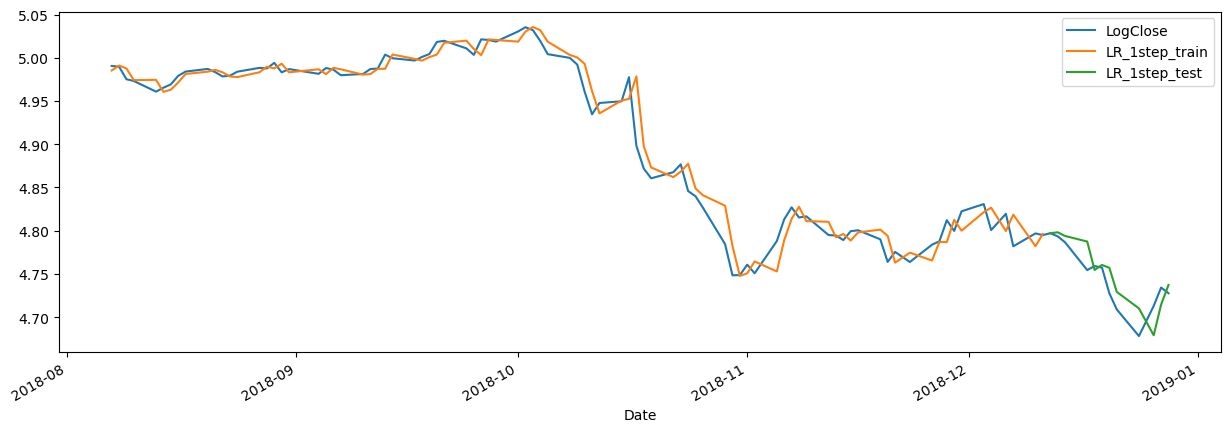

In [23]:
# plot 1 step forecast
cols = ['LogClose','LR_1step_train','LR_1step_test']
df.iloc[-100:][cols].plot(figsize = (15,5));

In [24]:
''' simply lagging the input time series'''

' simply lagging the input time series'

In [25]:
# multi step forecast
multistep_predictions = []

#first test input
last_x = Xtest[0] # an array of 10 input values for test set

while len(multistep_predictions) < Ntest:
    p = lr.predict(last_x.reshape(1,-1))[0] # since last_x is just one element, the shape gets messed up, we are changing the shape to 1*T 
    #scikit learn accepts data in the shape N*T only
    # at the end putting [0] since we want numeric output and not the array output

    # update the predictions list
    multistep_predictions.append(p)

    # make the new input 
    last_x = np.roll(last_x, -1) #[ 1 2 3 4 5] => [2 3 4 5 1] doing it this way since we cant delete or append anything to an array
    last_x[-1] = p # using the predictions from the previous horizon to make prediction for the next horizon

In [26]:
df.loc[test_idx, 'LR_multistep'] = last_train + np.cumsum(multistep_predictions)

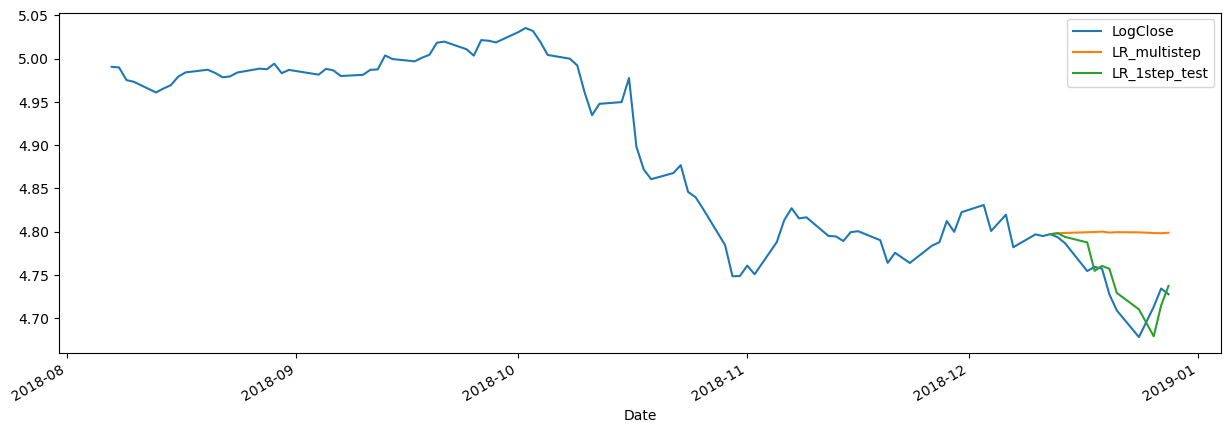

In [27]:
cols = ['LogClose','LR_multistep','LR_1step_test']
df.iloc[-100:][cols].plot(figsize = (15,5));

In [29]:
'''since it just copies the last known value, multistep is predicting the last known train value'''

'since it just copies the last known value, multistep is predicting the last known train value'

In [30]:
# making multi-output supervised dataset

Tx = T
Ty = Ntest
X = []
Y = []

for t in range(len(series) - Tx - Ty + 1):
    x = series[t:t+Tx]  
    y = series[t+Tx:t+Tx+Ty]  
    X.append(x)
    Y.append(y)
    # 1st x will have data inputs from 0 to 9 # 1st y will have data inputs from 10 to 21
    # 2nd x will have data inputs from 1 to 10 # 2nd y will have data inputs from 11 to 22

X = np.array(X).reshape(-1,Tx)
Y = np.array(Y).reshape(-1,Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

# converting this into numpy array since scikit learn only takes numpy array as an input
    

X.shape (2230, 21) Y.shape (2230, 12)


In [31]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [32]:
lr = LinearRegression()
lr.fit(Xtrain_m, Ytrain_m)
lr.score(Xtrain_m, Ytrain_m)

0.010010133087048345

In [34]:
from sklearn.metrics import r2_score
r2_score(lr.predict(Xtest_m).flatten(), Ytest_m.flatten())

-489.9493800611154

In [35]:
'''suggests that the data is just noise'''

'suggests that the data is just noise'

In [36]:
df.loc[test_idx, 'LR_multioutput'] = last_train + np.cumsum(lr.predict(Xtest_m).flatten())

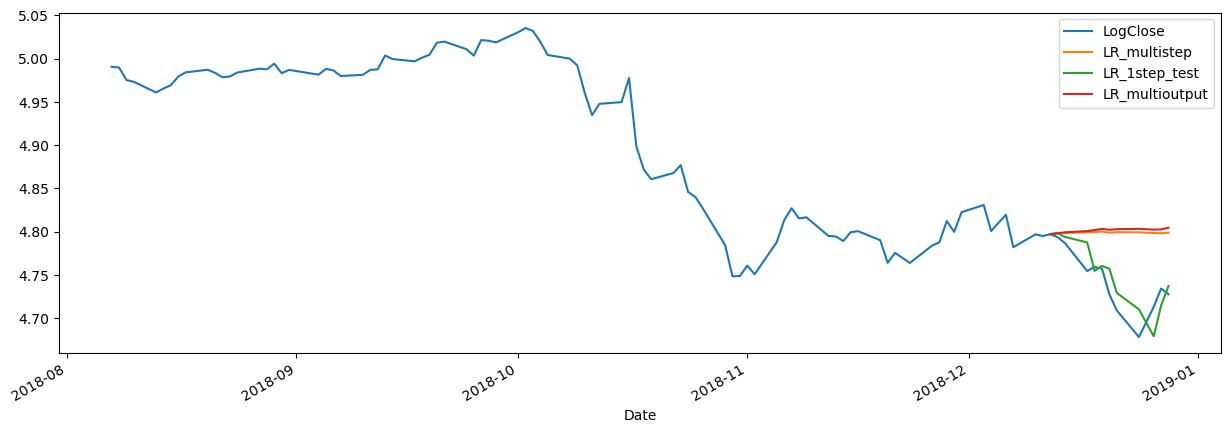

In [37]:
df.iloc[-100:][['LogClose','LR_multistep','LR_1step_test','LR_multioutput']].plot(figsize = (15,5));

In [39]:
''' follows same pattern - predicting last known value of training'''

' follows same pattern - predicting last known value of training'

In [41]:
from sklearn.metrics import mean_absolute_percentage_error
#MAPE - just checking other metrics
test_log_pass = df.iloc[-Ntest:]['LogClose']
mape_1 = mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'LR_multistep'])
print("multi-step MAPE:", mape_1)

mape_2 = mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'LR_multioutput'])
print("multi-output MAPE:", mape_2)

multi-step MAPE: 0.01142632609085105
multi-output MAPE: 0.011998190671272594


In [42]:
''' mape doesnt suggest it to be bad since denominator log close is of magnitude 4.7 and delta numerator is 0.1.
hence this is misleading'''

' mape doesnt suggest it to be bad since denominator log close is of magnitude 4.7 and delta numerator is 0.1.\nhence this is misleading'

## testing other models

In [44]:
def one_step_and_multistep_forecast(model, name):
    model.fit(Xtrain, Ytrain)
    print("One-step forecast:", name)

    # 1 step forecast
    df.loc[train_idx, f'{name}_1step_train'] = prev[train_idx] + model.predict(Xtrain)
    df.loc[test_idx, f'{name}_1step_test'] = prev[test_idx] + model.predict(Xtest)

    #generate multi-step forecast
    multistep_predictions =[]
    last_x = Xtest[0]

    while len(multistep_predictions) < Ntest:
        p = model.predict(last_x.reshape(1,-1))[0]

        multistep_predictions.append(p)

        last_x = np.roll(last_x,-1)
        last_x[-1] = p

    df.loc[test_idx, f'{name}_multistep_test'] = last_train + np.cumsum(multistep_predictions)

    mape = mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, f'{name}_multistep_test'])
    print("Test MAPE (multistep):", mape) 

    cols = [
        'LogClose',
        f'{name}_1step_train',
        f'{name}_1step_test',
        f'{name}_multistep_test'
    ]
    
    df.iloc[-100:][cols].plot(figsize =(15,5));    

One-step forecast: SVR
Test MAPE (multistep): 0.009692971150318395


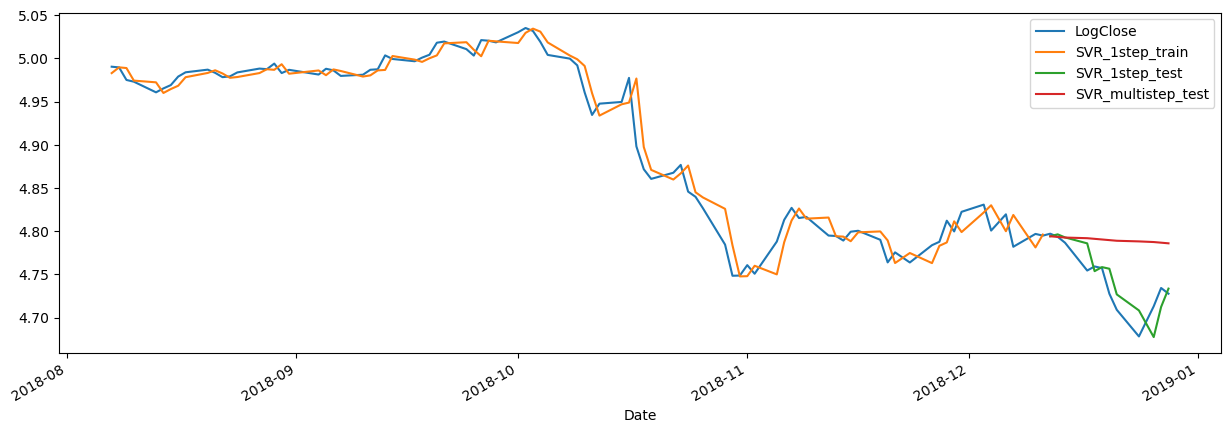

In [45]:
one_step_and_multistep_forecast(SVR(),"SVR")

In [48]:
'''does same thing'''

'does same thing'

One-step forecast: RF
Test MAPE (multistep): 0.01308010855956647


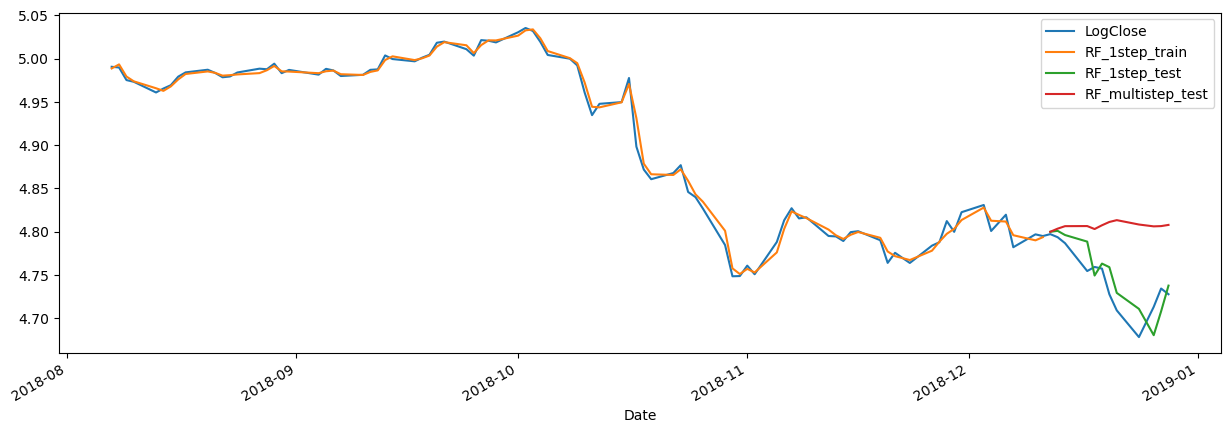

In [46]:
one_step_and_multistep_forecast(RandomForestRegressor(),"RF")

In [51]:
''' does same thing with rf overfitting the train set'''

' does same thing with rf overfitting the train set'

In [53]:
def multi_output_forecast(model, name):
    
    model.fit(Xtrain_m, Ytrain_m)
    
    # 1 step forecast
    
    df.loc[test_idx, f'{name}_multioutput'] = last_train + np.cumsum(model.predict(Xtest_m).flatten())

    mape = mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, f'{name}_multioutput'])
    print("Test MAPE (multi-output):", mape)
    
    #
    cols = [
        'LogClose',
        f'{name}_1step_train',
        f'{name}_1step_test',
        f'{name}_multistep_test',
        f'{name}_multioutput'
    ]
    
    df.iloc[-100:][cols].plot(figsize =(15,5));    

Test MAPE (multi-output): 0.011019292253979518


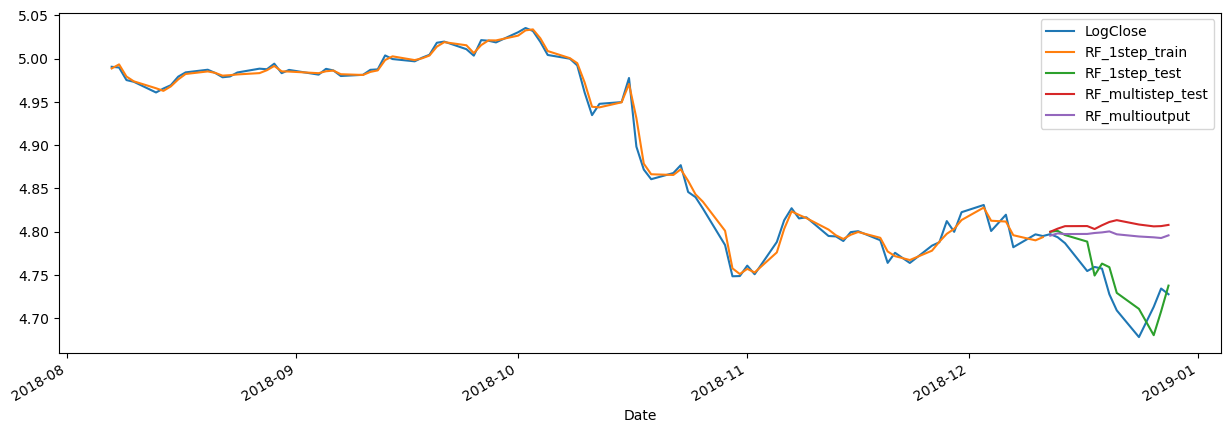

In [54]:
multi_output_forecast(RandomForestRegressor(),"RF")

In [55]:
''' same thing'''

' same thing'

# conclusion - same kind of results happenning in both linear and non linear models